# Prerequistes

In [48]:
%pip install qiskit qiskit-aer pylatexenc


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Quantum Phase Estimation (QPE)

/var/folders/bx/skxt34z93js03bl2brq7gw8m0000gn/T/ipykernel_76310/1408133989.py:36: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  iqft = QFT(num_qubits=t, inverse=True, do_swaps=True).to_gate()


### QPE Analysis: Hidden Phase Estimation

#### 1. Circuit Visualisation

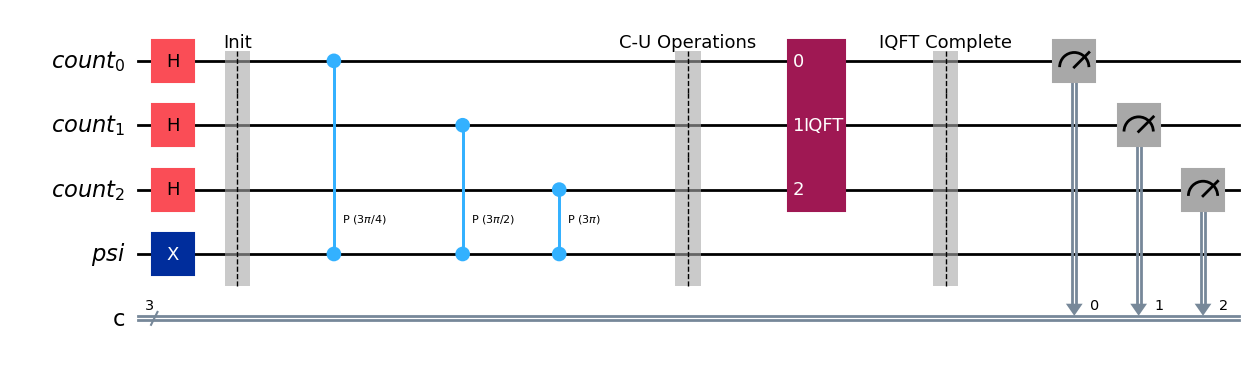

#### 2. Quantum State Representation

Final DensityMatrix of counting register prior to measurement:


<IPython.core.display.Latex object>

#### 3. State Visualisation

Counting register state prior to measurement (Bloch Spheres):


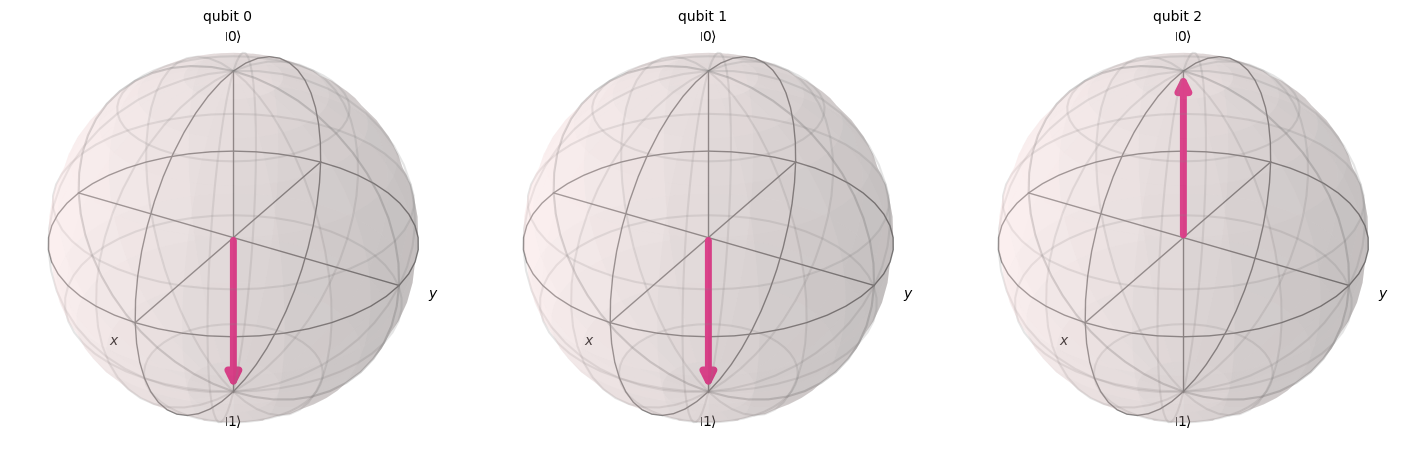


Counting register state prior to measurement (Q-Sphere):


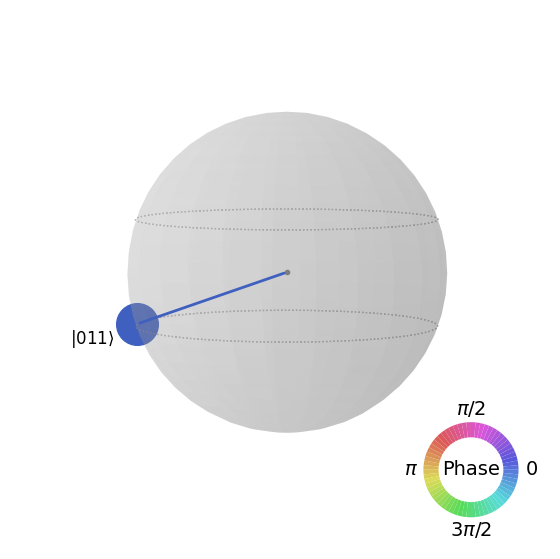

#### 4. Measurement Analysis

Raw measurement counts: {'011': 1024}


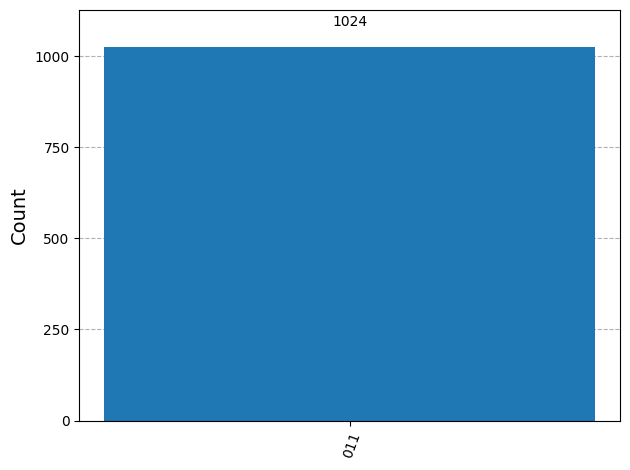

#### 5. Verification: Phase Calculation

Target Phase Set (θ): 0.375
Most frequent measurement: |011\rangle
Decimal equivalent: 3
Estimated Phase (θ) = 3 / 2^3 = 0.375
Success: The estimated phase perfectly matches the target hidden phase!


In [58]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
t = 3                  # Number of counting qubits
actual_theta = 0.375   # The hidden phase we want to estimate (e.g., 3/8)

# 1. Set up Registers & Circuit
# t counting qubits + 1 state qubit for the eigenvector
qr_count = QuantumRegister(t, name="count")
qr_state = QuantumRegister(1, name="psi")
cr = ClassicalRegister(t, name="c")
qc = QuantumCircuit(qr_count, qr_state, cr)

# 2. Initialisation
qc.x(qr_state[0])  # Prepare target register in eigenstate |1>
qc.h(qr_count)     # Prepare counting register in a superposition
qc.barrier(label="Init")

# 3. Apply Controlled Unitaries (U = PhaseGate(2 * pi * theta))
# Instead of a nested loop, we calculate the cumulative angle mathematically
for j in range(t):
    # The phase kicked back to the j-th qubit is U^(2^j)
    angle = 2 * np.pi * actual_theta * (2 ** j)
    qc.cp(angle, qr_count[j], qr_state[0])
qc.barrier(label="C-U Operations")

# 4. Apply Inverse QFT to counting register
iqft = QFT(num_qubits=t, inverse=True, do_swaps=True).to_gate()
iqft.name = "IQFT"
qc.append(iqft, qr_count)
qc.barrier(label="IQFT Complete")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
final_state = Statevector(qc)
rho_full = DensityMatrix(qc)
# Trace out the eigenstate qubit (index t) to view just the counting register
rho_count = partial_trace(rho_full, [t])

# 5. Measurement (measure only the counting register)
qc.measure(qr_count, cr)

# 6. Execute on AerSimulator
simulator = AerSimulator()
t_qc = transpile(qc, simulator)
job = simulator.run(t_qc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"### QPE Analysis: Hidden Phase Estimation"))

display(Markdown("#### 1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("#### 2. Quantum State Representation"))
print("Final DensityMatrix of counting register prior to measurement:")
display(rho_count.draw('latex'))

display(Markdown("#### 3. State Visualisation"))
print("Counting register state prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(rho_count))

print("\nCounting register state prior to measurement (Q-Sphere):")
display(plot_state_qsphere(rho_count))

display(Markdown("#### 4. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# 5. Final Verification Logic
display(Markdown("#### 5. Verification: Phase Calculation"))
measured_binary = list(counts.keys())[0]
measured_decimal = int(measured_binary, 2)
estimated_phase = measured_decimal / (2 ** t)

print(f"Target Phase Set (θ): {actual_theta}")
print(f"Most frequent measurement: |{measured_binary}\\rangle")
print(f"Decimal equivalent: {measured_decimal}")
print(f"Estimated Phase (θ) = {measured_decimal} / 2^{t} = {estimated_phase:.3f}")

if np.isclose(estimated_phase, actual_theta):
    print("Success: The estimated phase perfectly matches the target hidden phase!")
else:
    print("Note: The estimated phase is an approximation of the true phase (increase counting qubits for higher precision).")